   number_people                       date  timestamp  is_weekend  \
0             37  2015-08-14 17:00:11-07:00      61211           0   
1             45  2015-08-14 17:20:14-07:00      62414           0   
2             40  2015-08-14 17:30:15-07:00      63015           0   
3             44  2015-08-14 17:40:16-07:00      63616           0   
4             45  2015-08-14 17:50:17-07:00      64217           0   

   is_holiday  temperature  is_start_of_semester  is_during_semester  
0           0        71.76                     0                   0  
1           0        71.76                     0                   0  
2           0        71.76                     0                   0  
3           0        71.76                     0                   0  
4           0        71.76                     0                   0  
<class 'pandas.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  

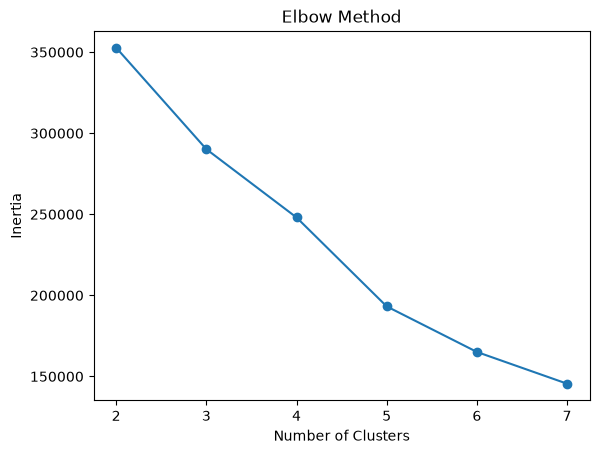


Cluster counts:
Cluster
1    32693
0    29331
2      160
Name: count, dtype: int64

Cluster Summary:
         number_people     timestamp  is_weekend  is_holiday  temperature  \
Cluster                                                                     
0            11.674815  29766.593979    0.331458         0.0    55.632669   
1            44.786652  60176.886367    0.240663         0.0    61.234691   
2             7.518750  47158.350000    0.000000         1.0    47.547812   

         is_start_of_semester  is_during_semester  
Cluster                                            
0                    0.036037            0.457127  
1                    0.117609            0.845655  
2                    0.000000            0.000000  


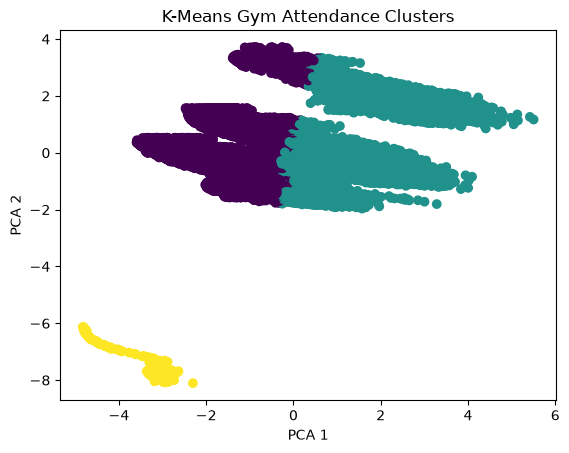

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6469/3950109499.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes("object").columns



NLP Cluster counts:
NLP_Cluster
2    28852
1    19809
0    13523
Name: count, dtype: int64

NLP Cluster 0:
2015, 12, 00, 08, 11, 07, 13, 10, 20, 09

NLP Cluster 1:
08, 2016, 00, 01, 12, 02, 11, 03, 20, 14

NLP Cluster 2:
07, 2016, 00, 05, 06, 04, 10, 09, 03, 15

Done! Results saved as gym_attendance_clustered.csv


In [1]:
# Gym Attendance - K-Means + NLP

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("gym_attendance.csv")
print(df.head())
print(df.info())

# 2. Numeric data for K-Means
num = df.select_dtypes("number").columns

X = df[num].fillna(df[num].median())
X = StandardScaler().fit_transform(X)

# 3. Elbow method
inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(2, 8), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# 4. K-Means
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X)

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# 5. Cluster summary
print("\nCluster Summary:")
print(df.groupby("Cluster")[list(num)].mean())

# 6. PCA visualisation
pca = PCA(n_components=2)
p = pca.fit_transform(X)

plt.scatter(p[:, 0], p[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Gym Attendance Clusters")
plt.show()

# 7. NLP - find text column automatically
text_cols = df.select_dtypes("object").columns

if len(text_cols) > 0:
    text = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

    # TF-IDF
    tfidf = TfidfVectorizer(stop_words="english")
    T = tfidf.fit_transform(text)

    # NLP K-Means
    nlp_km = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["NLP_Cluster"] = nlp_km.fit_predict(T)

    print("\nNLP Cluster counts:")
    print(df["NLP_Cluster"].value_counts())

    # Important words in each cluster
    words = tfidf.get_feature_names_out()

    for i in range(3):
        top = nlp_km.cluster_centers_[i].argsort()[-10:][::-1]
        print(f"\nNLP Cluster {i}:")
        print(", ".join(words[top]))

# 8. Save results
df.to_csv("gym_attendance_clustered.csv", index=False)

print("\nDone! Results saved as gym_attendance_clustered.csv")